### creating object with sync video and parse telemetry

In [1]:
from utilities.TelementryVideoSync import TelemetryVideoSync
from utilities.PX4CSVPlotter import PX4CSVPlotter
import os
from collections import namedtuple
import numpy as np
import pickle

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
DATA_DIR = "data/4/"
pickle_path = os.path.join(DATA_DIR, "data.pkl")
video_path = os.path.join(DATA_DIR, "input.mkv")
output_path = os.path.join(DATA_DIR, "output.mp4")
ulog_path = os.path.join(DATA_DIR, "ulg.ulg")
csv_path = os.path.join(DATA_DIR, "csv")
Data = namedtuple("Data", ["frames", "gps_time", "gps_alt", "yaw", "pitch", "roll"])

TELEMETRY_START_IDX = 3814
TELEMETRY_END_IDX = 13779

VIDEO_START_MESS = 15.233333333333333
VIDEO_END_MESS = 55.833333333333336

SAVE_EVERY_N = 1
PLOT_EVERY_N = 10




In [2]:


# --------------------------------------------------
# CREATE OBJECT
# --------------------------------------------------

sync = TelemetryVideoSync(
    telemetry_start_idx=TELEMETRY_START_IDX,
    telemetry_end_idx=TELEMETRY_END_IDX,
    video_start_time=VIDEO_START_MESS,
    video_end_time=VIDEO_END_MESS,
    video_path=video_path,
    ulog_path=ulog_path,
    csv_path=csv_path,
    save_every_n=SAVE_EVERY_N,
    plot_every_n=PLOT_EVERY_N,
)
# --------------------------------------------------
# PIPELINE
# --------------------------------------------------
# %matplotlib qt
# sync.debug_select_window_all()


In [3]:
import importlib
import utilities.PX4CSVPlotter
importlib.reload(utilities.PX4CSVPlotter)
from utilities.PX4CSVPlotter import PX4CSVPlotter

sync.debug_detect_motion_video()
# 1. Convert ULOG → CSV (run once)
sync.read_telemetry()


# 2. Load telemetry, cut, resample, load video frames
sync.analyze_telemetry()

# 3. Play synchronized telemetry video
sync.play_telemetry_video()

Video FPS: 30.0
Start frame index: 457
End frame index: 1675
Start time (s): 15.233333333333333
End time (s): 55.833333333333336
Duration (s): 40.6
Saved sensor_accel_0.csv
Saved sensor_baro_0.csv
Saved sensor_gps_0.csv
Saved sensor_gyro_0.csv
Saved sensor_mag_0.csv
Saved vehicle_attitude_0.csv
Saved vehicle_global_position_0.csv
Saved vehicle_local_position_0.csv
(14808,)
(14808,)
(14808,)
(14808,)
(14808,)
Video FPS: 30.0


Reading frames: 2250it [00:05, 389.33it/s]


Frames shape: (2250, 960, 1280, 3)
gps_time_cut: (1218,)
yaw_cut: (1218,)
pitch_cut: (1218,)
roll_cut: (1218,)
gps_alt_cut: (1218,)
frames_cut: (1218, 960, 1280, 3)


In [4]:
print("frames shape:", sync.frames.shape)
print("gps_time shape:", sync.gps_time.shape)
print("gps_alt shape:", sync.gps_alt.shape)
print("yaw shape:", sync.yaw.shape)
print("pitch shape:", sync.pitch.shape)
print("roll shape:", sync.roll.shape)

frames shape: (1218, 960, 1280, 3)
gps_time shape: (1218,)
gps_alt shape: (1218,)
yaw shape: (1218,)
pitch shape: (1218,)
roll shape: (1218,)


In [5]:



step = 1

data = Data(
    frames=np.array(sync.frames)[::step],
    gps_time=np.array(sync.gps_time)[::step],
    gps_alt=np.array(sync.gps_alt)[::step],
    yaw=np.array(sync.yaw)[::step],
    pitch=np.array(sync.pitch)[::step],
    roll=np.array(sync.roll)[::step],
)
del sync

In [6]:
with open(pickle_path, "wb") as f:
    pickle.dump(data, f)


In [7]:

del data

import gc
gc.collect()


29

## Analyzing part

In [8]:
from utilities.TelementryVideoSync import TelemetryVideoSync
from utilities.PX4CSVPlotter import PX4CSVPlotter
import os
from collections import namedtuple
import numpy as np
import pickle






In [9]:
import pickle


with open(pickle_path, "rb") as f:
    data = pickle.load(f)


In [10]:
every_n_row = 1

data = Data(*(arr[::every_n_row] for arr in data))

### ADDED:

In [11]:
import pandas as pd

#check if sensors detect relative height (dist_bottom)
df_loc = pd.read_csv("data/2/csv/vehicle_local_position_0.csv")
print(df_loc["dist_bottom"].describe())
print(df_loc["dist_bottom_valid"].value_counts())
print("\n")

#if not check from local position z (negative)
df_loc = pd.read_csv("data/2/csv/vehicle_local_position_0.csv")
print(df_loc["z"].describe())

count    18549.000000
mean        30.387550
std         20.909414
min          0.000000
25%          5.969791
50%         40.517307
75%         49.771000
max         49.906780
Name: dist_bottom, dtype: float64
dist_bottom_valid
0    18549
Name: count, dtype: int64


count    18549.000000
mean       -30.505329
std         20.927530
min        -50.030480
25%        -49.901290
50%        -40.648810
75%         -6.101475
max          0.675983
Name: z, dtype: float64


## DISTANCE TO BOTTOM (no valid data found)

### dist_bottom

| Statistic | Value |
|----------|------:|
| count | 18549.000000 |
| mean  | 30.387550 |
| std   | 20.909414 |
| min   | 0.000000 |
| 25%   | 5.969791 |
| 50%   | 40.517307 |
| 75%   | 49.771000 |
| max   | 49.906780 |

**Name:** dist_bottom
**Type:** dtype: float64

## dist_bottom_valid

| count |
|------:|
| 18549 |

---

## LOCAL POSITION (-z) found valid data - will be used as relative hight

### z

| Statistic | Value |
|----------|------:|
| count | 18549.000000 |
| mean  | -30.505329 |
| std   | 20.927530 |
| min   | -50.030480 |
| 25%   | -49.901290 |
| 50%   | -40.648810 |
| 75%   | -6.101475 |
| max   | 0.675983 |

**Name:** z
**Type:** dtype: float64

In [12]:
threshold = 5
exclude_first = 250
exclude_last = 400
mask = (np.abs(data.pitch) <= threshold) & (np.abs(data.roll) <= threshold)


mask = (np.abs(data.pitch) <= threshold) & (np.abs(data.roll) <= threshold)
mask[:exclude_first] = False
mask[-exclude_last:] = False

data = Data(
    frames=data.frames[mask],
    gps_time=data.gps_time[mask],
    gps_alt=data.gps_alt[mask],
    yaw=data.yaw[mask],
    pitch=data.pitch[mask],
    roll=data.roll[mask],
)



In [13]:
import cv2
import numpy as np

frames = data.frames
fps = 30  # set your desired fps
delay = int(1000 / fps)

for i, frame in enumerate(frames):
    if frame.shape[2] == 3:
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    else:
        frame_bgr = frame

    # add frame index text
    cv2.putText(
        frame_bgr,
        f"Frame: {i}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imshow("Filtered Frames", frame_bgr)

    if cv2.waitKey(delay) == 27:  # press ESC to exit
        break

cv2.destroyAllWindows()


In [14]:
# import cv2
# yaw = (data.yaw + 360) % 360
#
#
# rotated_frames = []
# for img, y in zip(data.frames, yaw):
#     M = cv2.getRotationMatrix2D((img.shape[1]/2, img.shape[0]/2), -y, 1)
#     rotated = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))
#     rotated_frames.append(rotated)
#
# data = Data(
#     frames=np.array(rotated_frames),
#     gps_time=data.gps_time,
#     gps_alt=data.gps_alt,
#     yaw=yaw,
#     pitch=data.pitch,
#     roll=data.roll,
# )


In [15]:
# import matplotlib.pyplot as plt
#
# SHOW_EVERY_N = 50
#
# n = min(
#     len(data.frames),
#     len(data.gps_time),
#     len(data.gps_alt),
#     len(data.yaw),
#     len(data.pitch),
#     len(data.roll),
# )
#
# for i in range(0, n, SHOW_EVERY_N):
#     fig, axes = plt.subplots(
#         2, 1,
#         figsize=(10, 7),
#         gridspec_kw={"height_ratios": [3, 1]}
#     )
#
#     # ---------- IMAGE ----------
#     axes[0].imshow(data.frames[i])
#     axes[0].set_title(f"Frame {i}")
#     axes[0].axis("off")
#
#     # ---------- TELEMETRY ----------
#     text = (
#         f"Time:  {data.gps_time[i]:.2f} s\n"
#         f"Alt:   {data.gps_alt[i]:.2f} m\n"
#         f"Yaw:   {data.yaw[i]:.2f} deg\n"
#         f"Pitch: {data.pitch[i]:.2f} deg\n"
#         f"Roll:  {data.roll[i]:.2f} deg"
#     )
#
#     axes[1].text(
#         0.05, 0.5,
#         text,
#         fontsize=12,
#         va="center",
#         ha="left"
#     )
#     axes[1].axis("off")
#
#     plt.tight_layout()
#     plt.show()


In [16]:
import numpy as np
import cv2

frames = data.frames

feature_params = dict(
    maxCorners=800,
    qualityLevel=0.03,
    minDistance=5,
    blockSize=5
)

lk_params = dict(
    winSize=(21, 21),      # bigger window for faster motion
    maxLevel=3,            # deeper pyramid for large movement
    criteria=(
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        30,
        0.01
    )
)


dx_list = []
dy_list = []

old_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

for i in range(1, len(frames)):
    frame_gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)

    # If no points to track, re-detect
    if p0 is None or len(p0) == 0:
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        if p0 is None:
            continue

    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # If tracking failed completely, re-detect points and skip
    if p1 is None or st is None:
        old_gray = frame_gray
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        continue

    good_new = p1[st == 1]
    good_old = p0[st == 1]

    if len(good_new) == 0:
        old_gray = frame_gray
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        continue

    flow = good_new - good_old

    dx = np.median(flow[:, 0])
    dy = np.median(flow[:, 1])

    dx_list.append(dx)
    dy_list.append(dy)

    old_gray = frame_gray
    p0 = good_new.reshape(-1, 1, 2)

print("Done!")


Done!


In [33]:
import numpy as np

def remove_spikes_mad(x, thresh=30):
    x = np.asarray(x)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return x
    z = 0.6745 * (x - med) / mad
    x_clean = x.copy()
    x_clean[np.abs(z) > thresh] = med
    return x_clean

# dx_list = remove_spikes_mad(dx_list)
# dy_list = remove_spikes_mad(dy_list)


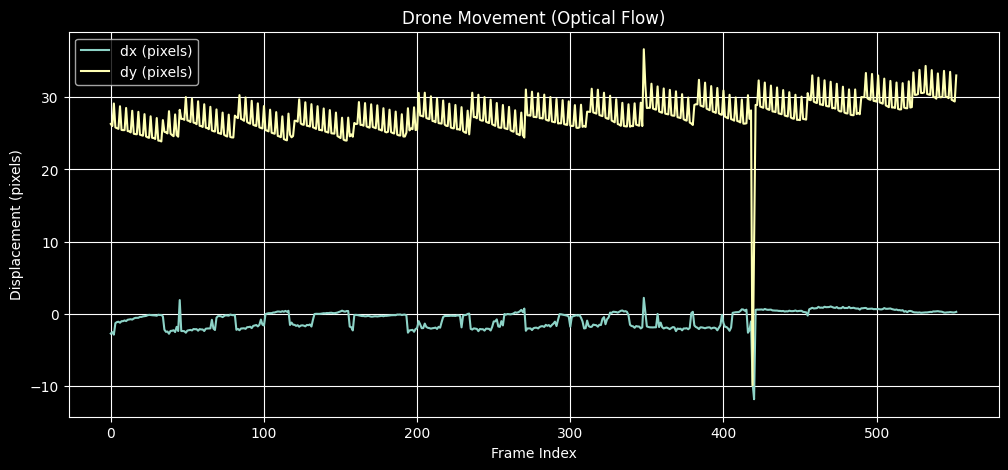

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(dx_list, label="dx (pixels)")
plt.plot(dy_list, label="dy (pixels)")
plt.title("Drone Movement (Optical Flow)")
plt.xlabel("Frame Index")
plt.ylabel("Displacement (pixels)")
plt.legend()
plt.grid(True)
plt.show()


agl raw mean: 1.4271051465832802
agl raw min: -0.6283684
agl raw max: 3.1346092
agl raw[:10]: [-0.00037676 -0.00038917 -0.000402   -0.0004154  -0.00042943 -0.00044348
 -0.00045791 -0.0004723  -0.00048607 -0.00049884]


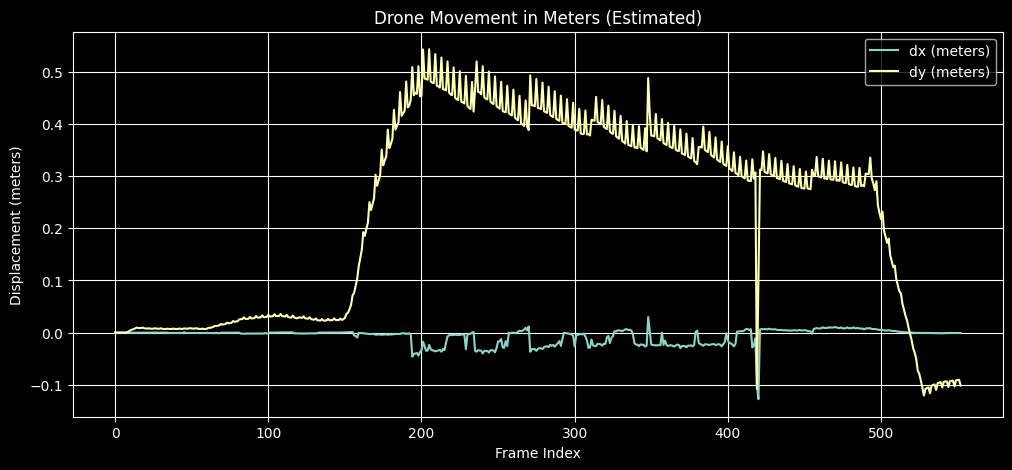

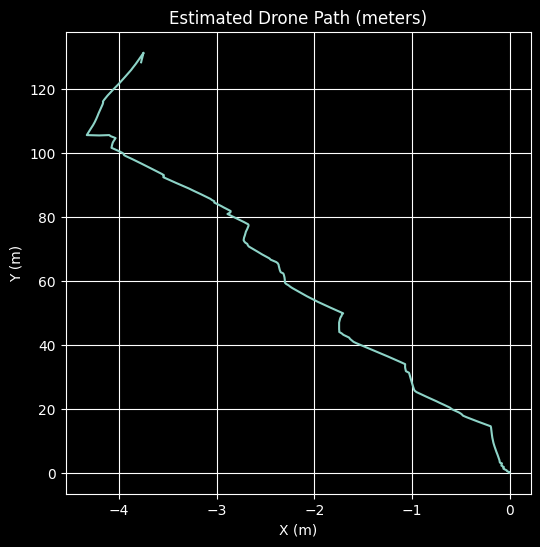

In [119]:
import numpy as np
import matplotlib.pyplot as plt

FOV_VERTICAL_DEG = 70

fov_rad = np.deg2rad(2 * FOV_VERTICAL_DEG)

img_h = data.frames[0].shape[0]

df_loc = pd.read_csv(os.path.join(csv_path, "vehicle_local_position_0.csv"))
agl = -df_loc["z"].to_numpy()
agl_resampled = np.interp(
    np.linspace(0, 1, len(data.gps_alt)),
    np.linspace(0, 1, len(agl)),
    agl
)

print("agl raw mean:", agl.mean())
print("agl raw min:", agl.min())
print("agl raw max:", agl.max())
print("agl raw[:10]:", agl[:10])

dist = df_loc["dist_bottom"].to_numpy()
dist_resampled = np.interp(
    np.linspace(0, 1, len(data.gps_alt)),
    np.linspace(0, 1, len(dist)),
    dist
)

# meters per pixel per frame (depends on altitude)
meters_per_pixel = 2 * agl_resampled[:len(dx_list)] * np.tan(fov_rad / 2) / img_h # local z position

#meters_per_pixel = 2 * dist_resampled[:len(dx_list)] * np.tan(fov_rad / 2) / img_h # dist bottom

#meters_per_pixel = 2 * data.gps_alt[:len(dx_list)] * np.tan(fov_rad / 2) / img_h # absolute GPS height

#meters_per_pixel = 2 * (data.gps_alt[:len(dx_list)] - data.gps_alt[0]) * np.tan(fov_rad / 2) / img_h

dx_m = np.array(dx_list) * meters_per_pixel
dy_m = np.array(dy_list) * meters_per_pixel

plt.figure(figsize=(12, 5))
plt.plot(dx_m, label="dx (meters)")
plt.plot(dy_m, label="dy (meters)")
plt.title("Drone Movement in Meters (Estimated)")
plt.xlabel("Frame Index")
plt.ylabel("Displacement (meters)")
plt.legend()
plt.grid(True)
plt.show()

x = np.cumsum(dx_m)
y = np.cumsum(dy_m)

plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.title("Estimated Drone Path (meters)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True)
plt.show()


In [95]:
HFOV_DEG = 90
img_h, img_w = data.frames[0].shape[:2]
vfov_rad = 2 * np.arctan(np.tan(np.deg2rad(HFOV_DEG/2)) * img_h / img_w)
print("Vertical FOV:", np.degrees(vfov_rad))

home = ulog.get_dataset('home_position')
print(home.data.keys())
print(home.data['alt'][:3])

Vertical FOV: 73.73979529168803
dict_keys(['timestamp', 'lat', 'lon', 'alt', 'x', 'y', 'z', 'roll', 'pitch', 'yaw', 'update_count', 'valid_alt', 'valid_hpos', 'valid_lpos', 'manual_home'])
[38.13373  38.13373  38.124943]


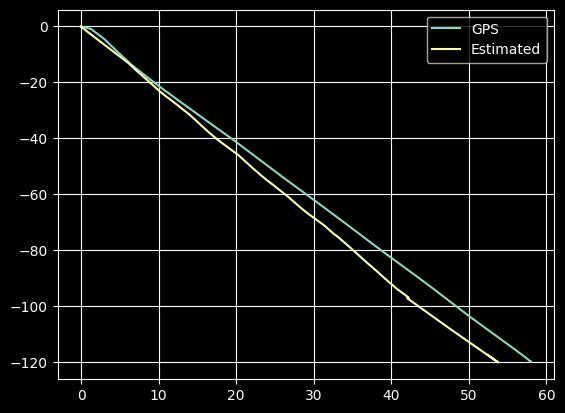

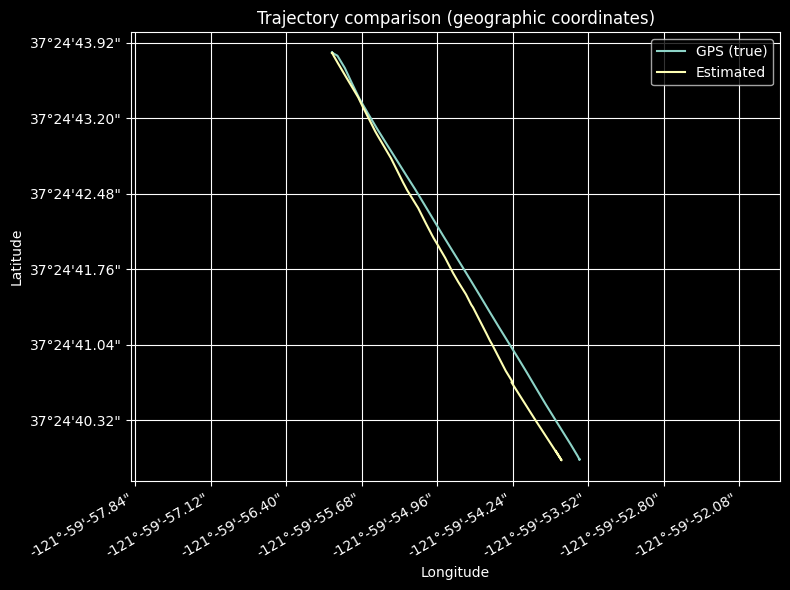

In [120]:
#ADDED -----------------------------------------------------------------
from utilities.GPS_conversion import GPSPosition

plotter = PX4CSVPlotter(csv_path)
_, gps_lon, gps_lat, _ = plotter.plot_gps(plot=False)

gps_conv = GPSPosition()

lat_est, lon_est = gps_conv.calculate_path(
    dy_m,
    dx_m,
    np.radians(data.yaw[:len(dx_m)]),
    gps_lat[0],
    gps_lon[0],
)

#print(data.yaw[:5])

plotter.plot_comparison(gps_lat, gps_lon, lat_est, lon_est)

plt.figure(figsize=(8, 6))
plt.plot(gps_lon, gps_lat, label="GPS (true)")
plt.plot(lon_est, lat_est, label="Estimated")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory comparison (geographic coordinates)")
plt.legend()
plt.grid()
plt.axis("equal")
PX4CSVPlotter.format_dms_axis(plt.gca())
plt.tight_layout()
plt.show()
# ----------------------------------------------------------------------

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, HTML

plotter = PX4CSVPlotter(csv_path)
_, gps_lon, gps_lat, _ = plotter.plot_gps(plot=False)
gps_conv = GPSPosition()

df_loc = pd.read_csv(os.path.join(csv_path, "vehicle_local_position_0.csv"))
agl = df_loc["z"].to_numpy()
agl_resampled = np.interp(
    np.linspace(0, 1, len(data.gps_alt)),
    np.linspace(0, 1, len(agl)),
    agl
)

img_h = data.frames[0].shape[0]

fig, ax = plt.subplots(figsize=(8, 6))

def update(fov):
    ax.clear()
    fov_rad = np.deg2rad(fov)
    meters_per_pixel = 2 * agl_resampled[:len(dx_list)] * np.tan(fov_rad / 2) / img_h

    dx_m = np.array(dx_list) * meters_per_pixel
    dy_m = np.array(dy_list) * meters_per_pixel

    lat_est, lon_est = gps_conv.calculate_path(
        -dy_m, dx_m,
        np.radians(data.yaw[:len(dx_m)]),
        gps_lat[0], gps_lon[0],
    )

    ax.plot(gps_lon, gps_lat, label="GPS (true)", color="cyan")
    ax.plot(lon_est, lat_est, label="Estimated", color="yellow")
    ax.set_title(f"FOV = {fov}°")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()
    ax.grid(True)

fov_range = range(20, 150)
ani = animation.FuncAnimation(fig, update, frames=fov_range, interval=150)
ani.save("fov_comparison.gif", writer="pillow", fps=7)
plt.close()
print("Saved!")

display(HTML(ani.to_jshtml()))
plt.close()

Saved!


# pamietać że to jest gps nie obcinany gdzie wielkości się nie zgadzają


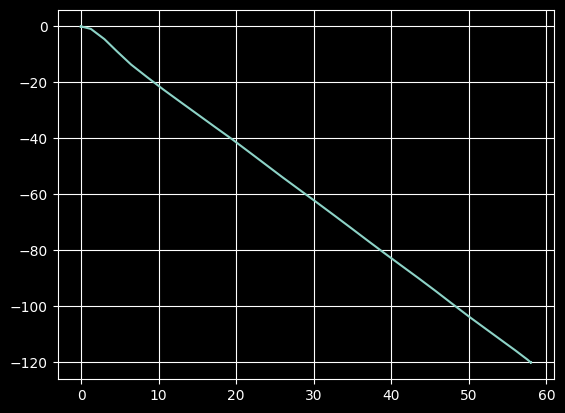

(array([ 5.48 ,  6.468,  7.492,  8.484,  9.472, 10.464, 11.484, 12.476,
        13.464, 14.488, 15.48 , 16.468, 17.492, 18.48 , 19.472, 20.46 ,
        21.484, 22.476, 23.464, 24.488, 25.476, 26.468, 27.492, 28.48 ,
        29.472, 30.492, 31.484, 32.472, 33.464, 34.488, 35.476, 36.468,
        37.488, 38.48 , 39.468, 40.492, 41.484, 42.472, 43.464, 44.484,
        45.476, 46.464, 47.488, 48.48 , 49.468, 50.492, 51.48 , 52.472,
        53.46 , 54.484, 55.476, 56.464, 57.488, 58.476, 59.468, 60.492,
        61.48 , 62.472, 63.492]),
 array([-121.99887888, -121.99887883, -121.99887856, -121.99887869,
        -121.99887872, -121.99887904, -121.9988788 , -121.99887896,
        -121.99887851, -121.99887856, -121.99887839, -121.99887859,
        -121.99887877, -121.99887875, -121.99887885, -121.99887878,
        -121.99888009, -121.99887935, -121.99887857, -121.99886457,
        -121.99884489, -121.99882615, -121.99880594, -121.9987828 ,
        -121.99875903, -121.99873345, -121.99870815, -

In [26]:
from utilities.PX4CSVPlotter import PX4CSVPlotter

# Wczytaj i wyświetl wszystkie wykresy
plotter = PX4CSVPlotter(csv_path)
plotter.plot_gps()